# 08. Interrupted Time Series

Interrupted time series, usually abbreviated ITS, is a quasi-experimental design for evaluating an intervention introduced at a clearly defined point in time. Instead of comparing treated and untreated units, the basic ITS design compares the post-intervention trajectory to the trajectory expected from the pre-intervention trend.

This design is common in industry because many interventions happen system-wide: a pricing rule changes, a fraud model launches, a marketplace policy goes live, a support workflow is replaced, a ranking algorithm is updated, or a compliance requirement begins on a known date.

ITS is strongest when we have many observations before and after the intervention, a stable measurement process, a well-defined intervention date, and careful modeling of secular trends, seasonality, and autocorrelation.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain when interrupted time series is appropriate.
- Distinguish level changes from slope changes.
- Fit a segmented regression model.
- Build and interpret a counterfactual continuation of the pre-intervention trend.
- Diagnose seasonality and autocorrelation.
- Use HAC standard errors for serially correlated residuals.
- Run sensitivity checks with alternative interruption dates.
- Extend ITS to a controlled interrupted time series with a comparison series.
- Translate an ITS result into an industry decision readout.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def add_season_terms(frame, period=12, harmonics=2):
    work = frame.copy()
    for k in range(1, harmonics + 1):
        work[f"sin{k}"] = np.sin(2 * np.pi * k * work["t"] / period)
        work[f"cos{k}"] = np.cos(2 * np.pi * k * work["t"] / period)
    return work


def add_its_terms(frame, intervention_month):
    work = frame.copy()
    work["post"] = (work["t"] >= intervention_month).astype(int)
    work["time_after"] = np.where(work["t"] >= intervention_month, work["t"] - intervention_month + 1, 0)
    return work


def fit_segmented_its(frame, outcome, intervention_month, include_season=True, hac_lags=12):
    work = add_its_terms(frame, intervention_month)
    terms = ["t", "post", "time_after"]
    if include_season:
        work = add_season_terms(work)
        terms += ["sin1", "cos1", "sin2", "cos2"]

    X = sm.add_constant(work[terms], has_constant="add")
    model = sm.OLS(work[outcome], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    conventional = sm.OLS(work[outcome], X).fit()
    return {"data": work, "model": model, "conventional_model": conventional, "terms": terms}


def prediction_frame(frame, terms, intervention_month, intervention_active=True):
    work = add_its_terms(frame, intervention_month)
    if not intervention_active:
        work["post"] = 0
        work["time_after"] = 0
    if any(term.startswith("sin") or term.startswith("cos") for term in terms):
        work = add_season_terms(work)
    X = sm.add_constant(work[terms], has_constant="add")
    return X


def coefficient_row(label, model, term):
    estimate = float(model.params[term])
    se = float(model.bse[term])
    return {
        "model_or_quantity": label,
        "term": term,
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": float(model.pvalues[term]),
    }


def plot_effect_table(table, title, reference=None):
    plot_table = table.dropna(subset=["estimate"]).copy().reset_index(drop=True)
    y = np.arange(len(plot_table))
    fig, ax = plt.subplots(figsize=(9, max(3.6, 0.55 * len(plot_table) + 1.4)))
    for i, row in plot_table.iterrows():
        if np.isfinite(row.get("ci_low", np.nan)) and np.isfinite(row.get("ci_high", np.nan)):
            ax.errorbar(
                row["estimate"],
                y[i],
                xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
                fmt="o",
                capsize=4,
                color="#2563eb",
                ecolor="#93c5fd",
            )
        else:
            ax.scatter(row["estimate"], y[i], color="#2563eb", s=45)
    if reference is not None:
        ax.axvline(reference, color="#16a34a", linestyle="--", linewidth=1.5, label="Reference")
        ax.legend()
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_table["model_or_quantity"])
    ax.invert_yaxis()
    ax.set_xlabel("Estimated effect")
    ax.set_title(title)
    return fig, ax

## 1. Where ITS Fits

ITS is useful when an intervention happens at a known time and randomization is unavailable. Wagner et al. (2002) describe segmented regression as a standard approach for estimating intervention effects in ITS studies. Bernal et al. (2016) emphasize that ITS is especially valuable for population-level interventions implemented at a clearly defined point in time.

Industry examples:

- A fraud-screening rule launches for the whole marketplace.
- A support automation workflow is deployed globally.
- A pricing fee change starts on a known date.
- A ranking algorithm changes for all users in a region.
- A compliance policy takes effect after a regulatory deadline.
- A data-quality rule changes the way events are recorded.

ITS asks whether the post-intervention path departs from the path implied by the pre-intervention trajectory.

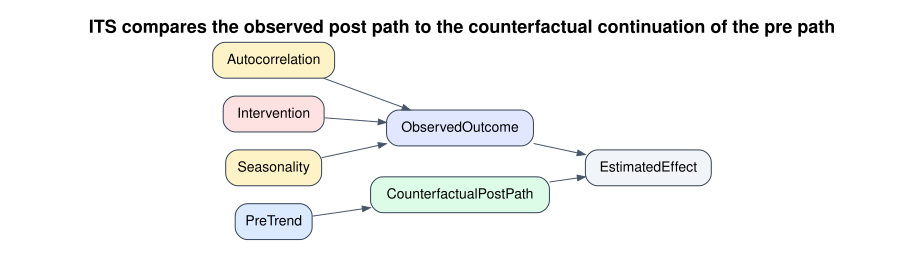

In [3]:
make_dag(
    edges=[
        ("PreTrend", "CounterfactualPostPath"),
        ("Seasonality", "ObservedOutcome"),
        ("Autocorrelation", "ObservedOutcome"),
        ("Intervention", "ObservedOutcome"),
        ("ObservedOutcome", "EstimatedEffect"),
        ("CounterfactualPostPath", "EstimatedEffect"),
    ],
    title="ITS compares the observed post path to the counterfactual continuation of the pre path",
    node_colors={
        "PreTrend": "#dbeafe",
        "CounterfactualPostPath": "#dcfce7",
        "Seasonality": "#fef3c7",
        "Autocorrelation": "#fef3c7",
        "Intervention": "#fee2e2",
        "ObservedOutcome": "#e0e7ff",
        "EstimatedEffect": "#f1f5f9",
    },
)

ITS is not simply a before/after comparison. The design uses multiple pre-intervention observations to estimate what would have happened after the intervention if the prior trajectory had continued.

## 2. Segmented Regression Model

A basic segmented regression model is:

$$
Y_t = \beta_0 + \beta_1t + \beta_2Post_t + \beta_3TimeAfter_t + \epsilon_t
$$

where:

- $t$ is the time index.
- $Post_t$ is 0 before the intervention and 1 after the intervention.
- $TimeAfter_t$ is 0 before the intervention and counts time since the intervention afterward.
- $\beta_2$ is the immediate level change.
- $\beta_3$ is the slope change after the intervention.

For monthly business data, we often add seasonal terms:

$$
Y_t = \beta_0 + \beta_1t + \beta_2Post_t + \beta_3TimeAfter_t + \gamma_1\sin(2\pi t / 12) + \gamma_2\cos(2\pi t / 12) + \epsilon_t
$$

The causal claim is that no other time-varying shock at the intervention date explains the break in the series.

## 3. Running Example: Fraud Review Policy

Suppose a marketplace launches a new fraud-review policy at month 43. The outcome is chargebacks per 10,000 orders. Lower is better.

The policy is expected to have:

- an immediate level reduction because the most obvious risky transactions are blocked quickly;
- a gradual slope reduction because model monitoring and investigation workflows improve over time.

We simulate 72 months of data: 42 months before launch and 30 months after launch. We also simulate a control marketplace that shares seasonality and market shocks but does not receive the policy.

In [4]:
def simulate_its_data(n_months=72, intervention_month=42, seed=8808):
    rng = np.random.default_rng(seed)
    rows = []

    common_shock = np.zeros(n_months)
    shock_prev = 0.0
    for t in range(n_months):
        shock_prev = 0.55 * shock_prev + rng.normal(0, 1.2)
        common_shock[t] = shock_prev

    for series in ["Treated marketplace", "Control marketplace"]:
        is_treated = series == "Treated marketplace"
        local_prev = 0.0
        for t in range(n_months):
            month = t + 1
            date = pd.Timestamp("2020-01-01") + pd.DateOffset(months=t)
            post = int(t >= intervention_month)
            time_after = max(0, t - intervention_month + 1)

            season = 4.0 * np.sin(2 * np.pi * t / 12) + 2.0 * np.cos(2 * np.pi * t / 12)
            baseline = 92 - 0.22 * t + season + common_shock[t]
            if not is_treated:
                baseline = 85 - 0.18 * t + 0.85 * season + 0.90 * common_shock[t]

            true_policy_effect = 0.0
            if is_treated:
                true_policy_effect = -8.0 * post - 0.28 * time_after

            local_prev = 0.45 * local_prev + rng.normal(0, 1.6)
            outcome = baseline + true_policy_effect + local_prev

            rows.append(
                {
                    "series": series,
                    "month": month,
                    "date": date,
                    "t": t,
                    "post": post,
                    "time_after": time_after,
                    "chargebacks_per_10k": outcome,
                    "true_policy_effect": true_policy_effect,
                }
            )

    return pd.DataFrame(rows)


intervention_month = 42
df_its = simulate_its_data(intervention_month=intervention_month)
treated = df_its.loc[df_its["series"] == "Treated marketplace"].copy()
control = df_its.loc[df_its["series"] == "Control marketplace"].copy()

summary = (
    df_its.groupby("series")
    .agg(
        months=("month", "count"),
        pre_months=("post", lambda s: int((s == 0).sum())),
        post_months=("post", lambda s: int((s == 1).sum())),
        avg_chargebacks=("chargebacks_per_10k", "mean"),
    )
)
display(summary.round(3))

,months,pre_months,post_months,avg_chargebacks
series,,,,
Control marketplace,72,42,30,79.243
Treated marketplace,72,42,30,79.510


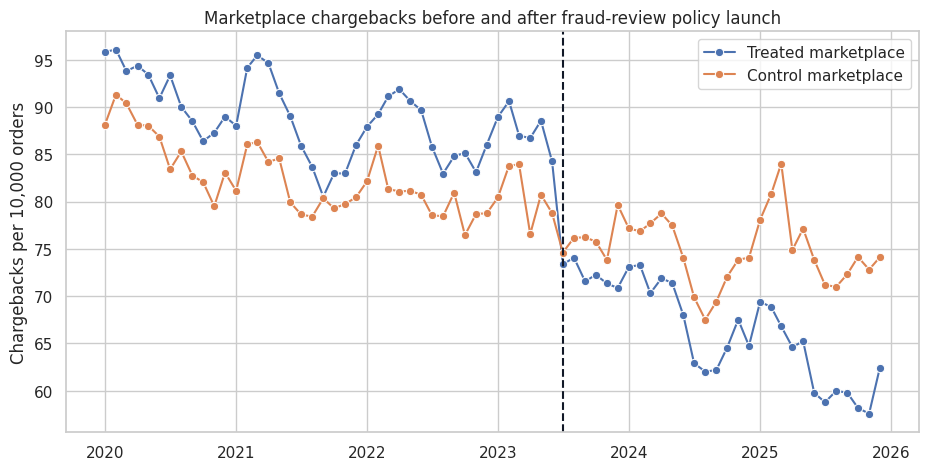

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.2))
sns.lineplot(data=df_its, x="date", y="chargebacks_per_10k", hue="series", marker="o", ax=ax)
ax.axvline(treated.loc[treated["t"] == intervention_month, "date"].iloc[0], color="#111827", linestyle="--", linewidth=1.5)
ax.set_title("Marketplace chargebacks before and after fraud-review policy launch")
ax.set_xlabel("")
ax.set_ylabel("Chargebacks per 10,000 orders")
ax.legend(title="")
plt.show()

The treated marketplace is improving before launch because fraud operations were already maturing. A plain before/after comparison would confuse this pre-existing trend with the policy effect.

## 4. Naive Before/After Is Not ITS

A simple before/after average ignores trend and seasonality. It answers:

> Were average chargebacks lower after launch than before launch?

That is not the same as:

> Did chargebacks fall below the level expected from the pre-launch trend?

In [6]:
naive_before_after = (
    treated.loc[treated["post"] == 1, "chargebacks_per_10k"].mean()
    - treated.loc[treated["post"] == 0, "chargebacks_per_10k"].mean()
)

naive_table = pd.DataFrame(
    {
        "quantity": ["Pre average", "Post average", "Naive post - pre"],
        "value": [
            treated.loc[treated["post"] == 0, "chargebacks_per_10k"].mean(),
            treated.loc[treated["post"] == 1, "chargebacks_per_10k"].mean(),
            naive_before_after,
        ],
    }
)
display(naive_table.round(3))

,quantity,value
0,Pre average,88.764
1,Post average,66.553
2,Naive post - pre,-22.211


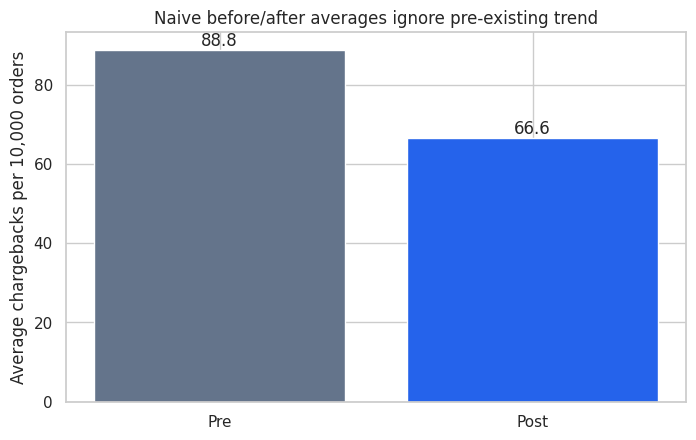

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.8))
period_means = treated.assign(period=np.where(treated["post"] == 1, "Post", "Pre")).groupby("period")["chargebacks_per_10k"].mean().reindex(["Pre", "Post"])
ax.bar(period_means.index, period_means.values, color=["#64748b", "#2563eb"])
ax.set_title("Naive before/after averages ignore pre-existing trend")
ax.set_ylabel("Average chargebacks per 10,000 orders")
for i, value in enumerate(period_means.values):
    ax.text(i, value + 1, f"{value:.1f}", ha="center")
plt.show()

The naive estimate is often too dramatic when the outcome was already trending in the desired direction. ITS models the pre-intervention path directly.

## 5. Fit Segmented Regression

We fit a segmented regression with time, post indicator, time after intervention, and seasonal sine/cosine terms. We use heteroskedasticity and autocorrelation consistent standard errors because monthly observations are often serially correlated.

In [8]:
segmented = fit_segmented_its(
    treated,
    outcome="chargebacks_per_10k",
    intervention_month=intervention_month,
    include_season=True,
    hac_lags=12,
)
segmented_model = segmented["model"]

segmented_table = pd.DataFrame(
    [
        coefficient_row("Immediate level change", segmented_model, "post"),
        coefficient_row("Monthly slope change", segmented_model, "time_after"),
    ]
)
display(segmented_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Immediate level change,post,-9.750,0.948,-11.609,-7.891,0.000
1,Monthly slope change,time_after,-0.336,0.050,-0.433,-0.238,0.000


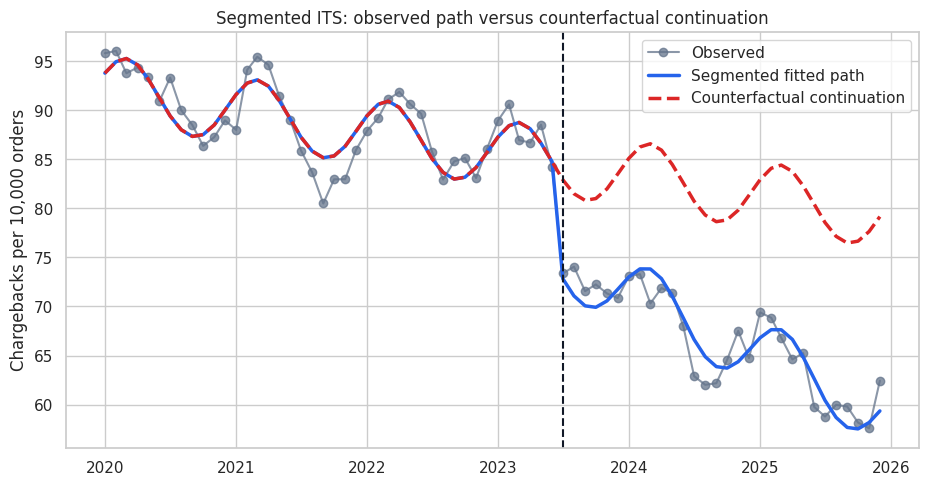

In [9]:
observed_X = prediction_frame(treated, segmented["terms"], intervention_month, intervention_active=True)
counterfactual_X = prediction_frame(treated, segmented["terms"], intervention_month, intervention_active=False)

treated_plot = treated.copy()
treated_plot["fitted"] = segmented_model.predict(observed_X)
treated_plot["counterfactual"] = segmented_model.predict(counterfactual_X)
treated_plot["estimated_effect"] = treated_plot["fitted"] - treated_plot["counterfactual"]

fig, ax = plt.subplots(figsize=(11, 5.4))
ax.plot(treated_plot["date"], treated_plot["chargebacks_per_10k"], marker="o", color="#64748b", alpha=0.75, label="Observed")
ax.plot(treated_plot["date"], treated_plot["fitted"], color="#2563eb", linewidth=2.5, label="Segmented fitted path")
ax.plot(treated_plot["date"], treated_plot["counterfactual"], color="#dc2626", linestyle="--", linewidth=2.5, label="Counterfactual continuation")
ax.axvline(treated_plot.loc[treated_plot["t"] == intervention_month, "date"].iloc[0], color="#111827", linestyle="--", linewidth=1.5)
ax.set_title("Segmented ITS: observed path versus counterfactual continuation")
ax.set_xlabel("")
ax.set_ylabel("Chargebacks per 10,000 orders")
ax.legend()
plt.show()

The vertical gap between the fitted observed path and the counterfactual continuation is the estimated policy effect. The gap can grow over time if the slope changes after the intervention.

In [10]:
post_effects = treated_plot.loc[treated_plot["post"] == 1, ["date", "month", "estimated_effect", "true_policy_effect"]].copy()
effect_summary = pd.DataFrame(
    {
        "quantity": [
            "Estimated immediate effect",
            "True immediate effect in simulation",
            "Estimated effect at final month",
            "True effect at final month in simulation",
            "Average estimated post effect",
            "Average true post effect in simulation",
        ],
        "value": [
            post_effects["estimated_effect"].iloc[0],
            post_effects["true_policy_effect"].iloc[0],
            post_effects["estimated_effect"].iloc[-1],
            post_effects["true_policy_effect"].iloc[-1],
            post_effects["estimated_effect"].mean(),
            post_effects["true_policy_effect"].mean(),
        ],
    }
)
display(effect_summary.round(3))

,quantity,value
0,Estimated immediate effect,-10.086
1,True immediate effect in simulation,-8.280
2,Estimated effect at final month,-19.821
3,True effect at final month in simulation,-16.400
4,Average estimated post effect,-14.953
5,Average true post effect in simulation,-12.340


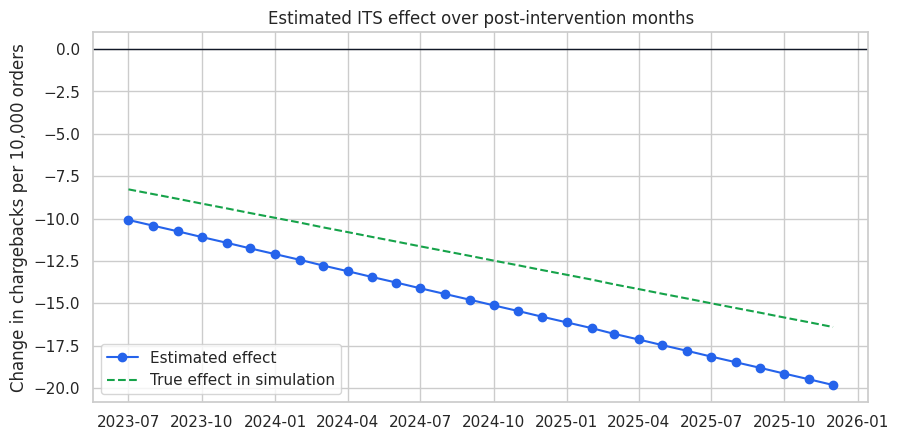

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(post_effects["date"], post_effects["estimated_effect"], marker="o", color="#2563eb", label="Estimated effect")
ax.plot(post_effects["date"], post_effects["true_policy_effect"], linestyle="--", color="#16a34a", label="True effect in simulation")
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Estimated ITS effect over post-intervention months")
ax.set_xlabel("")
ax.set_ylabel("Change in chargebacks per 10,000 orders")
ax.legend()
plt.show()

In real data, there is no true policy-effect column. We include it here only to verify that the estimator is learning the intended simulated signal.

## 6. Seasonality Matters

Monthly business metrics often have seasonal structure. If seasonality is correlated with the intervention date, a model without seasonal controls may attribute seasonal movement to the intervention.

In [12]:
segmented_no_season = fit_segmented_its(
    treated,
    outcome="chargebacks_per_10k",
    intervention_month=intervention_month,
    include_season=False,
    hac_lags=12,
)

season_comparison = pd.DataFrame(
    [
        coefficient_row("No seasonality: level change", segmented_no_season["model"], "post"),
        coefficient_row("With seasonality: level change", segmented_model, "post"),
        coefficient_row("No seasonality: slope change", segmented_no_season["model"], "time_after"),
        coefficient_row("With seasonality: slope change", segmented_model, "time_after"),
    ]
)
display(season_comparison.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,No seasonality: level change,post,-10.490,1.112,-12.669,-8.312,0.000
1,With seasonality: level change,post,-9.750,0.948,-11.609,-7.891,0.000
2,No seasonality: slope change,time_after,-0.332,0.048,-0.428,-0.237,0.000
3,With seasonality: slope change,time_after,-0.336,0.050,-0.433,-0.238,0.000


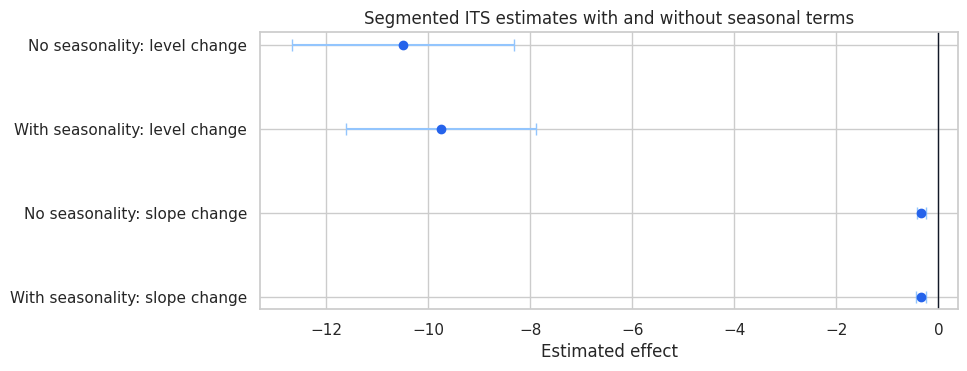

In [13]:
plot_effect_table(
    season_comparison,
    title="Segmented ITS estimates with and without seasonal terms",
)
plt.show()

Seasonality controls do not make ITS causal by themselves. They keep predictable calendar patterns from being mistaken for treatment effects.

## 7. Autocorrelation and Standard Errors

Time series residuals are often correlated. If residuals are autocorrelated and we use ordinary regression standard errors, uncertainty can be understated. Bernal et al. (2016) recommend checking residual autocorrelation and using methods such as autoregressive models or other corrections when needed.

Here we compare conventional OLS standard errors with HAC standard errors.

In [14]:
conventional_model = segmented["conventional_model"]
se_comparison = pd.DataFrame(
    [
        {
            "term": "post",
            "estimate": segmented_model.params["post"],
            "conventional_se": conventional_model.bse["post"],
            "hac_se": segmented_model.bse["post"],
        },
        {
            "term": "time_after",
            "estimate": segmented_model.params["time_after"],
            "conventional_se": conventional_model.bse["time_after"],
            "hac_se": segmented_model.bse["time_after"],
        },
    ]
)
display(se_comparison.round(3))

,term,estimate,conventional_se,hac_se
0,post,-9.750,0.981,0.948
1,time_after,-0.336,0.050,0.050


In [15]:
residuals = segmented_model.resid
ljung_box = acorr_ljungbox(residuals, lags=[1, 3, 6, 12], return_df=True)
diagnostic_table = pd.DataFrame(
    {
        "diagnostic": ["Durbin-Watson"] + [f"Ljung-Box lag {lag}" for lag in ljung_box.index],
        "value": [durbin_watson(residuals)] + ljung_box["lb_stat"].tolist(),
        "p_value": [np.nan] + ljung_box["lb_pvalue"].tolist(),
    }
)
display(diagnostic_table.round(3))

,diagnostic,value,p_value
0,Durbin-Watson,1.118,NaN
1,Ljung-Box lag 1,12.915,0.000
2,Ljung-Box lag 3,14.970,0.002
3,Ljung-Box lag 6,23.907,0.001
4,Ljung-Box lag 12,24.950,0.015


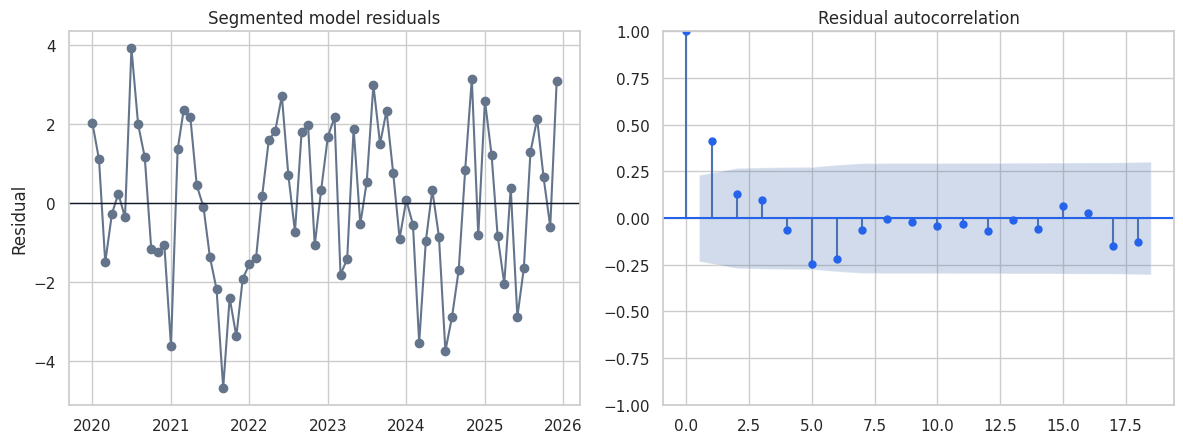

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(treated_plot["date"], residuals, marker="o", color="#64748b")
axes[0].axhline(0, color="#111827", linewidth=1)
axes[0].set_title("Segmented model residuals")
axes[0].set_xlabel("")
axes[0].set_ylabel("Residual")

plot_acf(residuals, lags=18, ax=axes[1], color="#2563eb")
axes[1].set_title("Residual autocorrelation")
plt.tight_layout()
plt.show()

The goal is not to eliminate every trace of autocorrelation. The goal is to avoid pretending that serially correlated monthly data contain as much independent information as unrelated observations.

## 8. Placebo Interruption Dates

A useful falsification check is to move the intervention date to fake pre-intervention dates. If the model finds large breaks at many placebo dates, the series may have unstable dynamics unrelated to the intervention.

In [17]:
placebo_months = [18, 24, 30, 36]
placebo_rows = []
for fake_month in placebo_months:
    pre_only = treated.loc[treated["t"] < intervention_month].copy()
    placebo_fit = fit_segmented_its(
        pre_only,
        outcome="chargebacks_per_10k",
        intervention_month=fake_month,
        include_season=True,
        hac_lags=6,
    )
    row = coefficient_row(f"Fake interruption at month {fake_month + 1}", placebo_fit["model"], "post")
    row["fake_month"] = fake_month + 1
    placebo_rows.append(row)

placebo_table = pd.DataFrame(placebo_rows)
display(placebo_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value,fake_month
0,Fake interruption at month 19,post,-2.285,1.045,-4.333,-0.236,0.029,19
1,Fake interruption at month 25,post,2.398,0.969,0.499,4.297,0.013,25
2,Fake interruption at month 31,post,2.841,1.819,-0.725,6.406,0.118,31
3,Fake interruption at month 37,post,2.140,0.989,0.203,4.078,0.030,37


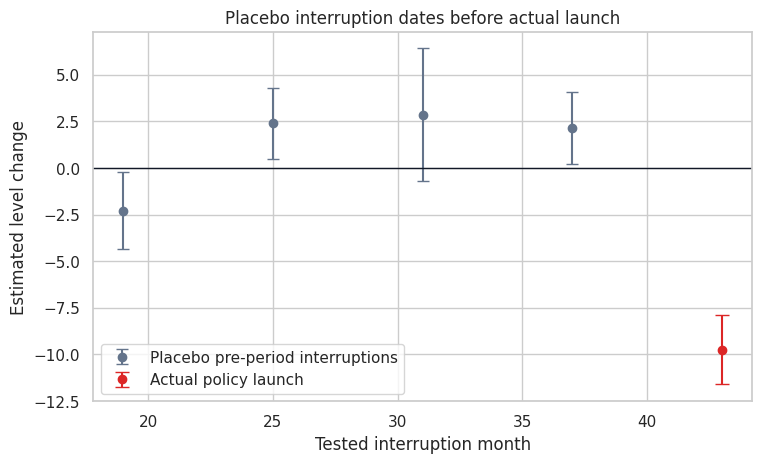

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    placebo_table["fake_month"],
    placebo_table["estimate"],
    yerr=1.96 * placebo_table["std_error"],
    fmt="o",
    capsize=4,
    color="#64748b",
    label="Placebo pre-period interruptions",
)
ax.errorbar(
    [intervention_month + 1],
    [segmented_model.params["post"]],
    yerr=[1.96 * segmented_model.bse["post"]],
    fmt="o",
    capsize=5,
    color="#dc2626",
    label="Actual policy launch",
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Placebo interruption dates before actual launch")
ax.set_xlabel("Tested interruption month")
ax.set_ylabel("Estimated level change")
ax.legend()
plt.show()

Placebo tests are not formal proof. They are stress tests for the story that the observed break is special to the actual intervention date.

## 9. Phase-In Windows

Many interventions do not turn on instantly. Fraud-review policies, support workflows, and ML systems may have a launch window where teams are still ramping. One practical sensitivity check is to exclude the phase-in months immediately after launch.

In [19]:
def fit_with_phase_in_gap(frame, outcome, intervention_month, gap_months):
    work = frame.loc[~frame["t"].between(intervention_month, intervention_month + gap_months - 1)].copy()
    work = work.reset_index(drop=True)
    return fit_segmented_its(work, outcome, intervention_month, include_season=True, hac_lags=12)

phase_rows = []
for gap in [0, 1, 2, 3, 4]:
    if gap == 0:
        fitted = segmented
    else:
        fitted = fit_with_phase_in_gap(treated, "chargebacks_per_10k", intervention_month, gap)
    row_level = coefficient_row(f"Exclude {gap} phase-in months: level", fitted["model"], "post")
    row_slope = coefficient_row(f"Exclude {gap} phase-in months: slope", fitted["model"], "time_after")
    row_level["gap_months"] = gap
    row_slope["gap_months"] = gap
    phase_rows.extend([row_level, row_slope])

phase_table = pd.DataFrame(phase_rows)
display(phase_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value,gap_months
0,Exclude 0 phase-in months: level,post,-9.750,0.948,-11.609,-7.891,0.000,0
1,Exclude 0 phase-in months: slope,time_after,-0.336,0.050,-0.433,-0.238,0.000,0
2,Exclude 1 phase-in months: level,post,-9.834,1.015,-11.822,-7.845,0.000,1
3,Exclude 1 phase-in months: slope,time_after,-0.332,0.054,-0.438,-0.225,0.000,1
4,Exclude 2 phase-in months: level,post,-10.350,0.929,-12.171,-8.528,0.000,2
5,Exclude 2 phase-in months: slope,time_after,-0.306,0.048,-0.400,-0.211,0.000,2
6,Exclude 3 phase-in months: level,post,-10.753,0.859,-12.436,-9.069,0.000,3
7,Exclude 3 phase-in months: slope,time_after,-0.286,0.045,-0.375,-0.197,0.000,3
8,Exclude 4 phase-in months: level,post,-11.454,0.659,-12.746,-10.162,0.000,4
9,Exclude 4 phase-in months: slope,time_after,-0.253,0.037,-0.326,-0.179,0.000,4


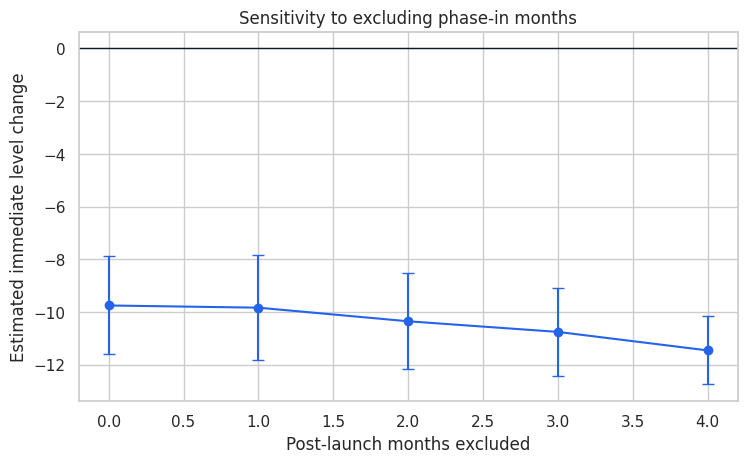

In [20]:
phase_plot = phase_table.loc[phase_table["term"] == "post"].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    phase_plot["gap_months"],
    phase_plot["estimate"],
    yerr=1.96 * phase_plot["std_error"],
    fmt="o-",
    capsize=4,
    color="#2563eb",
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Sensitivity to excluding phase-in months")
ax.set_xlabel("Post-launch months excluded")
ax.set_ylabel("Estimated immediate level change")
plt.show()

If estimates are highly sensitive to excluding one or two launch months, the intervention may have a ramp-up shape that needs to be modeled explicitly.

## 10. Controlled Interrupted Time Series

A comparison series can help address time-varying shocks that affect treated and control units at the same time. Controlled ITS is especially useful when seasonality, macro shocks, measurement changes, or market-wide events may coincide with the intervention.

A simple controlled ITS model estimates the additional post-intervention level and slope change in the treated series relative to the control series.

In [21]:
panel = df_its.copy()
panel["treated"] = (panel["series"] == "Treated marketplace").astype(int)
panel = add_its_terms(panel, intervention_month)
panel = add_season_terms(panel)
panel["treated_post"] = panel["treated"] * panel["post"]
panel["treated_time_after"] = panel["treated"] * panel["time_after"]

controlled_terms = [
    "t",
    "post",
    "time_after",
    "treated",
    "treated_post",
    "treated_time_after",
    "sin1",
    "cos1",
    "sin2",
    "cos2",
]
X_controlled = sm.add_constant(panel[controlled_terms], has_constant="add")
controlled_model = sm.OLS(panel["chargebacks_per_10k"], X_controlled).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 12},
)

controlled_table = pd.DataFrame(
    [
        coefficient_row("Controlled ITS: extra treated level change", controlled_model, "treated_post"),
        coefficient_row("Controlled ITS: extra treated slope change", controlled_model, "treated_time_after"),
    ]
)
display(controlled_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Controlled ITS: extra treated level change,treated_post,-8.245,1.280,-10.753,-5.737,0.000
1,Controlled ITS: extra treated slope change,treated_time_after,-0.429,0.060,-0.546,-0.311,0.000


In [22]:
combined_comparison = pd.DataFrame(
    [
        coefficient_row("Single-series ITS: level change", segmented_model, "post"),
        coefficient_row("Controlled ITS: level change", controlled_model, "treated_post"),
        coefficient_row("Single-series ITS: slope change", segmented_model, "time_after"),
        coefficient_row("Controlled ITS: slope change", controlled_model, "treated_time_after"),
    ]
)
display(combined_comparison.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Single-series ITS: level change,post,-9.750,0.948,-11.609,-7.891,0.000
1,Controlled ITS: level change,treated_post,-8.245,1.280,-10.753,-5.737,0.000
2,Single-series ITS: slope change,time_after,-0.336,0.050,-0.433,-0.238,0.000
3,Controlled ITS: slope change,treated_time_after,-0.429,0.060,-0.546,-0.311,0.000


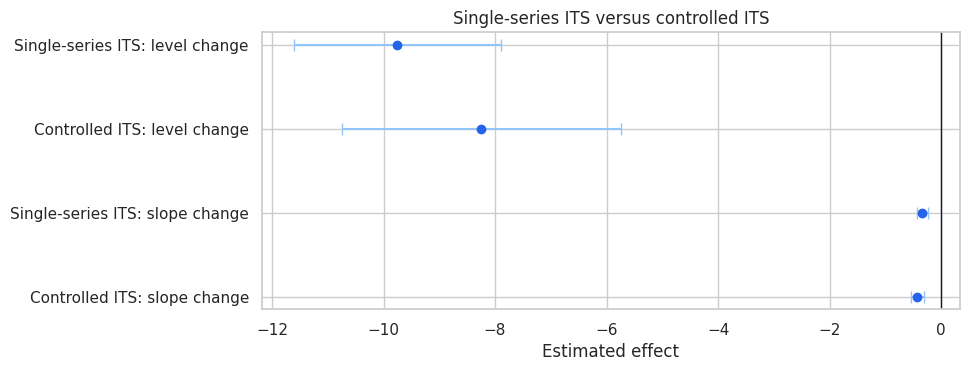

In [23]:
plot_effect_table(
    combined_comparison,
    title="Single-series ITS versus controlled ITS",
)
plt.show()

The control series is not a magic fix. It helps only if it captures the shocks that would otherwise confound the treated series and is not itself affected by the intervention.

## 11. What Can Go Wrong?

ITS is vulnerable when something else changes at the same time as the intervention.

Common threats:

- another policy launched at the same date;
- measurement or logging changed at the same date;
- seasonality was not modeled;
- the intervention date was selected after looking at the data;
- the outcome was already bending before launch;
- autocorrelation was ignored;
- the post period is too short;
- the intervention ramps gradually but the model assumes an immediate shift;
- a control series is contaminated by the treatment.

Good ITS work is as much about timeline forensics as regression.

In [24]:
checklist = pd.DataFrame(
    {
        "design_question": [
            "Is the intervention date known before analysis?",
            "Are there enough observations before and after?",
            "Is the measurement process stable?",
            "Are trend and seasonality modeled?",
            "Is residual autocorrelation checked?",
            "Are placebo dates tested?",
            "Is there a credible comparison series?",
            "Could another event explain the break?",
            "Is the launch immediate or phased?",
        ],
        "why_it_matters": [
            "Avoids choosing the break point after seeing the outcome.",
            "ITS needs enough pre data to estimate a counterfactual trend.",
            "Logging changes can mimic treatment effects.",
            "Calendar patterns can look like intervention effects.",
            "Serial dependence can understate uncertainty.",
            "Fake breaks reveal unstable pre-period dynamics.",
            "Controls help absorb common shocks.",
            "History threats are central in ITS.",
            "Phase-in affects level and slope interpretation.",
        ],
    }
)
display(checklist)

,design_question,why_it_matters
0,Is the intervention date known before analysis?,Avoids choosing the break point after seeing t...
1,Are there enough observations before and after?,ITS needs enough pre data to estimate a counte...
2,Is the measurement process stable?,Logging changes can mimic treatment effects.
3,Are trend and seasonality modeled?,Calendar patterns can look like intervention e...
4,Is residual autocorrelation checked?,Serial dependence can understate uncertainty.
5,Are placebo dates tested?,Fake breaks reveal unstable pre-period dynamics.
6,Is there a credible comparison series?,Controls help absorb common shocks.
7,Could another event explain the break?,History threats are central in ITS.
8,Is the launch immediate or phased?,Phase-in affects level and slope interpretation.


## 12. Industry Readout Template

A decision-facing ITS report should not begin with the regression table. It should begin with the timeline and the design claim.

In [25]:
readout = pd.DataFrame(
    {
        "item": [
            "Business question",
            "Intervention",
            "Intervention date",
            "Outcome",
            "Preferred design",
            "Estimated immediate level change",
            "Estimated monthly slope change",
            "Estimated final-month effect",
            "Main diagnostics",
            "Main threat",
            "Decision implication",
        ],
        "value": [
            "Did the fraud-review policy reduce chargebacks?",
            "Marketplace fraud-review policy launch",
            str(treated_plot.loc[treated_plot["t"] == intervention_month, "date"].iloc[0].date()),
            "Chargebacks per 10,000 orders",
            "Segmented ITS with seasonality and HAC standard errors; controlled ITS as sensitivity",
            f"{segmented_model.params['post']:.2f}",
            f"{segmented_model.params['time_after']:.2f} per month",
            f"{post_effects['estimated_effect'].iloc[-1]:.2f}",
            "Seasonality, residual autocorrelation, placebo dates, phase-in, comparison series",
            "Another event or measurement change at launch date could mimic the break",
            "The policy appears to reduce chargebacks immediately and increasingly over time.",
        ],
    }
)
display(readout)

,item,value
0,Business question,Did the fraud-review policy reduce chargebacks?
1,Intervention,Marketplace fraud-review policy launch
2,Intervention date,2023-07-01
3,Outcome,"Chargebacks per 10,000 orders"
4,Preferred design,Segmented ITS with seasonality and HAC standar...
5,Estimated immediate level change,-9.75
6,Estimated monthly slope change,-0.34 per month
7,Estimated final-month effect,-19.82
8,Main diagnostics,"Seasonality, residual autocorrelation, placebo..."
9,Main threat,Another event or measurement change at launch ...


## Key Takeaways

- ITS estimates whether a post-intervention trajectory deviates from the counterfactual continuation of the pre-intervention trajectory.
- Segmented regression separates immediate level changes from slope changes.
- A before/after average is not an ITS design.
- Seasonality and autocorrelation are central modeling concerns for business time series.
- HAC standard errors are a practical way to make inference less naive under serial correlation.
- Placebo interruption dates and phase-in sensitivity checks help stress-test the design.
- Controlled ITS adds a comparison series to absorb common shocks, but the control must be untreated and relevant.
- ITS credibility depends on timeline knowledge: what else changed, how measurement worked, and whether the intervention date was chosen before seeing the outcome.

## References

Bernal, J. L., Cummins, S., & Gasparrini, A. (2016). Interrupted time series regression for the evaluation of public health interventions: A tutorial. *International Journal of Epidemiology*. https://doi.org/10.1093/ije/dyw098

Penfold, R. B., & Zhang, F. (2013). Use of interrupted time series analysis in evaluating health care quality improvements. *Academic Pediatrics, 13*(6), S38-S44. https://doi.org/10.1016/j.acap.2013.08.002

Slavova, S., Costich, J. F., Luu, H., et al. (2018). Interrupted time series design to evaluate the effect of the ICD-9-CM to ICD-10-CM coding transition on injury hospitalization trends. *Injury Epidemiology, 5*, 36. https://doi.org/10.1186/s40621-018-0165-8

Taljaard, M., McKenzie, J. E., Ramsay, C. R., & Grimshaw, J. M. (2014). The use of segmented regression in analysing interrupted time series studies: An example in pre-hospital ambulance care. *Implementation Science, 9*, 77. https://doi.org/10.1186/1748-5908-9-77

Wagner, A. K., Soumerai, S. B., Zhang, F., & Ross-Degnan, D. (2002). Segmented regression analysis of interrupted time series studies in medication use research. *Journal of Clinical Pharmacy and Therapeutics, 27*(4), 299-309. https://doi.org/10.1046/j.1365-2710.2002.00430.x